In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
import joblib

In [2]:
df = pd.read_csv(r"D:\Materi Kuliah\SEMESTER 6\KPL\UTS\dataset\agro_environmental_dataset.csv")

df.head()

,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


In [3]:
print("Info Data:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated:", df.duplicated().sum())

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime            543210 

In [4]:
df = df.drop_duplicates()

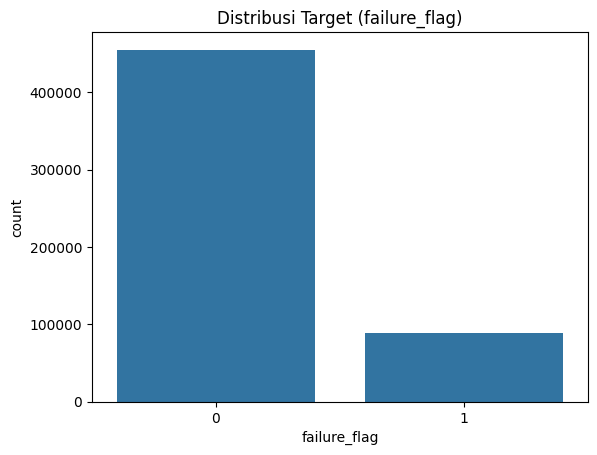

In [5]:
sns.countplot(x="failure_flag", data=df)
plt.title("Distribusi Target (failure_flag)")
plt.show()

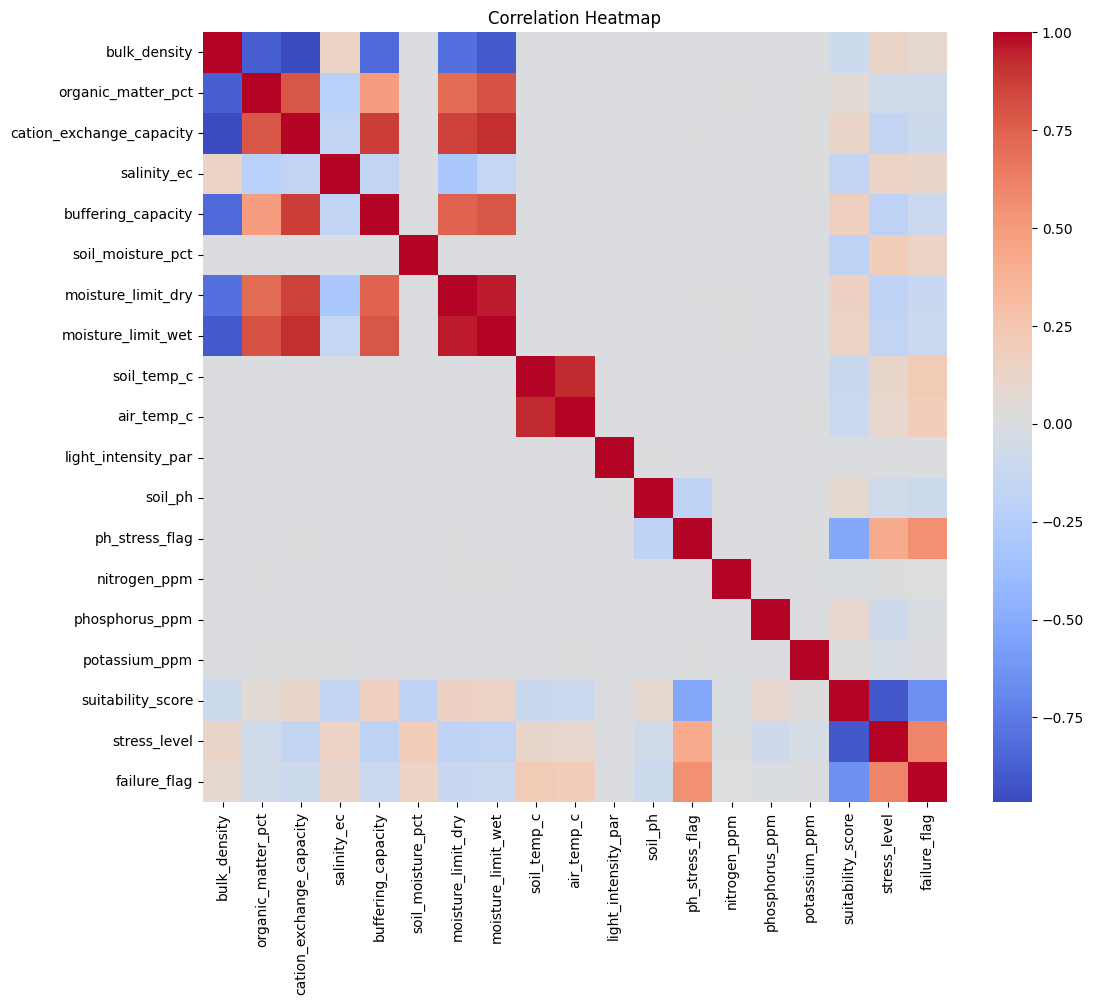

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [7]:
target_col = "failure_flag"

# Drop rows with NaN values in the target column before splitting
df_cleaned = df.dropna(subset=[target_col])

X = df_cleaned.drop([target_col, "location_id"], axis=1)
y = df_cleaned[target_col]

In [8]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [9]:
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [10]:
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

ModuleNotFoundError: No module named 'imblearn'

In [15]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
y_pred = model.predict(X_test)

# Diagnostic prints to check y_test
print(f"NaNs in y_test before evaluation: {y_test.isnull().sum()}")
print(f"Unique values in y_test before evaluation: {y_test.unique()}")

# Ensure y_test is clean and integer-typed for classification metrics
y_test_cleaned = y_test.dropna().astype(int)
y_pred_cleaned = y_pred[y_test.notnull()].astype(int)


print("Accuracy:", accuracy_score(y_test_cleaned, y_pred_cleaned))
print("\nClassification Report:\n", classification_report(y_test_cleaned, y_pred_cleaned))

NaNs in y_test before evaluation: 1
Unique values in y_test before evaluation: [ 0.  1. nan]
Accuracy: 0.9993887530562348

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1358
           1       1.00      1.00      1.00       278

    accuracy                           1.00      1636
   macro avg       1.00      1.00      1.00      1636
weighted avg       1.00      1.00      1.00      1636



In [21]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

model = grid.best_estimator_

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [23]:
y_pred = model.predict(X_test)

# Ensure y_test_cleaned and y_pred_cleaned are used for final evaluation
y_test_cleaned = y_test.dropna().astype(int)
y_pred_cleaned = y_pred[y_test.notnull()].astype(int)

print("Final Accuracy:", accuracy_score(y_test_cleaned, y_pred_cleaned))
print("\nFinal Report:\n", classification_report(y_test_cleaned, y_pred_cleaned))

Final Accuracy: 0.9993887530562348

Final Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1358
           1       1.00      1.00      1.00       278

    accuracy                           1.00      1636
   macro avg       1.00      1.00      1.00      1636
weighted avg       1.00      1.00      1.00      1636

